In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
tapogee_scores = pd.read_csv("../tAPOGEE/checkpoints/tAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
tapogee_scores

,Start,Ref,Alt,Gene_symbol,gene.position,tAPOGEE_score,tAPOGEE_oob_score,tAPOGEE_posterior,category
Mithril_id,,,,,,,,,
MITHRIL.1728,577,G,A,MT-TF,1,0.780641,0.780641,0.994751,pathogenic
MITHRIL.1729,577,G,C,MT-TF,1,0.703568,0.703568,0.951709,likely pathogenic
MITHRIL.1730,577,G,T,MT-TF,1,0.767472,0.767472,0.991911,pathogenic
MITHRIL.1731,578,T,A,MT-TF,2,0.520965,0.520965,0.320783,VUS
MITHRIL.1732,578,T,C,MT-TF,2,0.632326,0.632326,0.791225,VUS
...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,MT-TP,2,0.665709,0.665709,0.887440,VUS
MITHRIL.48240,16022,T,G,MT-TP,2,0.773280,0.773280,0.993295,pathogenic
MITHRIL.48241,16023,G,A,MT-TP,1,0.841406,0.834604,0.999351,pathogenic


In [3]:
categories = ["benign", "likely benign", "VUS", "likely pathogenic", "pathogenic"]
colors = plt.get_cmap("RdYlGn_r")(np.linspace(0, 1, len(categories)))
bins = np.linspace(0,1,51)
# Pre-compute histograms (counts) for each category
hist_data_tapogee = {}
for cat in categories:
    # Compute counts for the given bins for this category.
    counts, _ = np.histogram(tapogee_scores.loc[tapogee_scores.category == cat, "tAPOGEE_oob_score"], bins=bins)
    hist_data_tapogee[cat] = (len(bins)-1)*counts/len(tapogee_scores)
hist_data_tapogee

{'benign': array([0.      , 0.      , 0.      , 0.088476, 0.088476, 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
        0.      , 0.      ]),
 'likely benign': array([0.        , 0.        , 0.        , 0.        , 0.088476  ,
        0.55297501, 0.80734351, 0.90687901, 0.96217651, 1.22760451,
        1.00641451, 1.08383101, 0.95111701, 1.08383101, 0.99535501,
        1.10595001, 0.88476001, 1.09489051, 1.13912851, 1.11700951,
        1.18336651, 0.4534395 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0. 

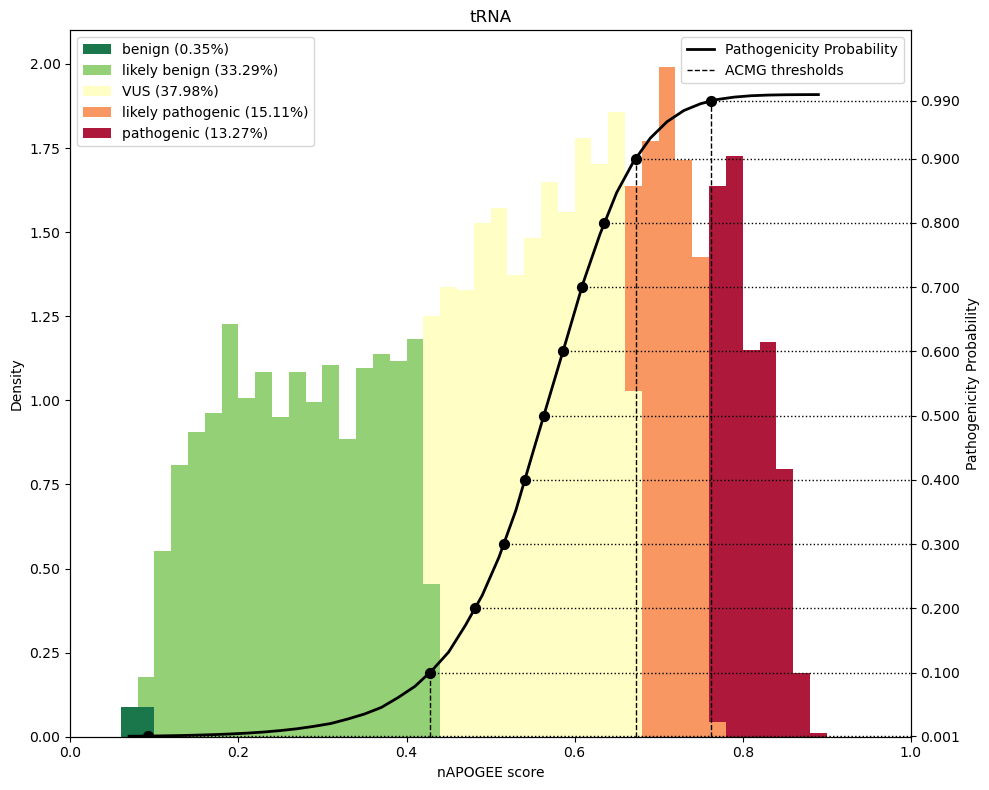

In [4]:
bins_posterior = tapogee_scores.groupby(pd.cut(tapogee_scores.tAPOGEE_oob_score, bins), observed=False).tAPOGEE_posterior.mean()
bins_posterior.index = (bins[:-1] + bins[1:])/2

# Create figure and primary axis (ax1) for the histogram
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot stacked histogram on primary y-axis
bottom = np.zeros(len(bins) - 1)
for i, cat in enumerate(categories):
    ax1.bar(
        bins[:-1], hist_data_tapogee[cat], width=np.diff(bins),
        bottom=bottom, color=colors[i], alpha=0.9, align='edge',
        label="%s (%.2f%%)" % (cat, (tapogee_scores.category == cat).mean() * 100)
    )
    bottom += hist_data_tapogee[cat]

ax1.set_ylim(-0, 2.1)
ax1.set_xlim(0, 1)
ax1.set_xlabel("nAPOGEE score")
ax1.set_ylabel("Density")
ax1.set_title("tRNA")
ax1.legend(loc="upper left")

# Create secondary axis (ax2) for the posterior values
ax2 = ax1.twinx()
line, = ax2.plot(bins_posterior.index, bins_posterior.values, "k-", linewidth=2, label="Pathogenicity Probability")
proba_ticks = np.linspace(0, 1, 11)
proba_ticks[0] = 0.001
proba_ticks[-1] = 0.99
scores_at_proba_ticks = np.interp(proba_ticks, bins_posterior.values, bins_posterior.index)
plt.scatter(scores_at_proba_ticks, proba_ticks, color="k", s=50)
ax2.hlines(proba_ticks, scores_at_proba_ticks, 1, colors="k", ls=":", lw=1)
ax2.vlines(
    scores_at_proba_ticks[np.isin(proba_ticks, [0.001, 0.1, 0.9, 0.99])], # x
    0, proba_ticks[np.isin(proba_ticks, [0.001, 0.1, 0.9, 0.99])], # y
    colors="k", ls="--", lw=1, label="ACMG thresholds"
)
ax2.set_yticks(proba_ticks)
ax2.set_ylabel("Pathogenicity Probability")
ax2.set_ylim(-0, 1.1)
ax2.legend(loc="upper right")


plt.tight_layout()
plt.savefig("./svg/tAPOGEE_distribution.svg", bbox_inches="tight")
plt.show()

In [ ]:
rapogee_scores = pd.read_csv("../rAPOGEE/checkpoints/rAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
rapogee_scores

,Start,Ref,Alt,Gene_symbol,Gene_position,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob,rAPOGEE_posterior,category
Mithril_id,,,,,,,,,,
MITHRIL.1941,648,A,C,MT-RNR1,1,0.262367,0.18,0.262367,3.686973e-07,benign
MITHRIL.1942,648,A,G,MT-RNR1,1,0.213403,0.10,0.212121,1.252327e-08,benign
MITHRIL.1943,648,A,T,MT-RNR1,1,0.239221,0.14,0.239221,8.477167e-08,benign
MITHRIL.1944,649,A,C,MT-RNR1,2,0.343674,0.36,0.343674,2.726607e-05,benign
MITHRIL.1945,649,A,G,MT-RNR1,2,0.351951,0.38,0.351951,3.986997e-05,benign
...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,MT-RNR2,1558,0.266290,0.18,0.266290,4.669735e-07,benign
MITHRIL.9684,3228,T,G,MT-RNR2,1558,0.302205,0.26,0.302205,3.505524e-06,benign
MITHRIL.9685,3229,T,A,MT-RNR2,1559,0.455647,0.60,0.455647,2.478844e-03,likely benign


In [ ]:
categories = ["benign", "likely benign", "VUS", "likely pathogenic", "pathogenic"]
colors = plt.get_cmap("RdYlGn_r")(np.linspace(0, 1, len(categories)))
bins = np.linspace(0,1,101)
# Pre-compute histograms (counts) for each category
hist_data_rapogee = {}
for cat in categories:
    # Compute counts for the given bins for this category.
    counts, _ = np.histogram(rapogee_scores.loc[rapogee_scores.category == cat, "rAPOGEE_oob"], bins=bins)
    hist_data_rapogee[cat] = (len(bins)-1)*counts/len(rapogee_scores)
hist_data_rapogee

{'benign': array([0.0663482 , 0.        , 0.01326964, 0.0663482 , 0.07961783,
        0.05307856, 0.09288747, 0.10615711, 0.19904459, 0.22558386,
        0.45116773, 0.41135881, 0.65021231, 0.62367304, 0.75636943,
        0.99522293, 1.10138004, 0.94214437, 1.19426752, 1.14118896,
        1.40658174, 1.53927813, 1.63216561, 1.38004246, 1.41985138,
        2.03025478, 2.01698514, 1.79140127, 2.04352442, 2.13641189,
        2.40180467, 2.44161359, 2.40180467, 2.25583864, 2.16295117,
        2.12314225, 2.37526539, 2.13641189, 2.10987261, 2.242569  ,
        2.13641189, 2.26910828, 2.18949045, 0.03980892, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.    

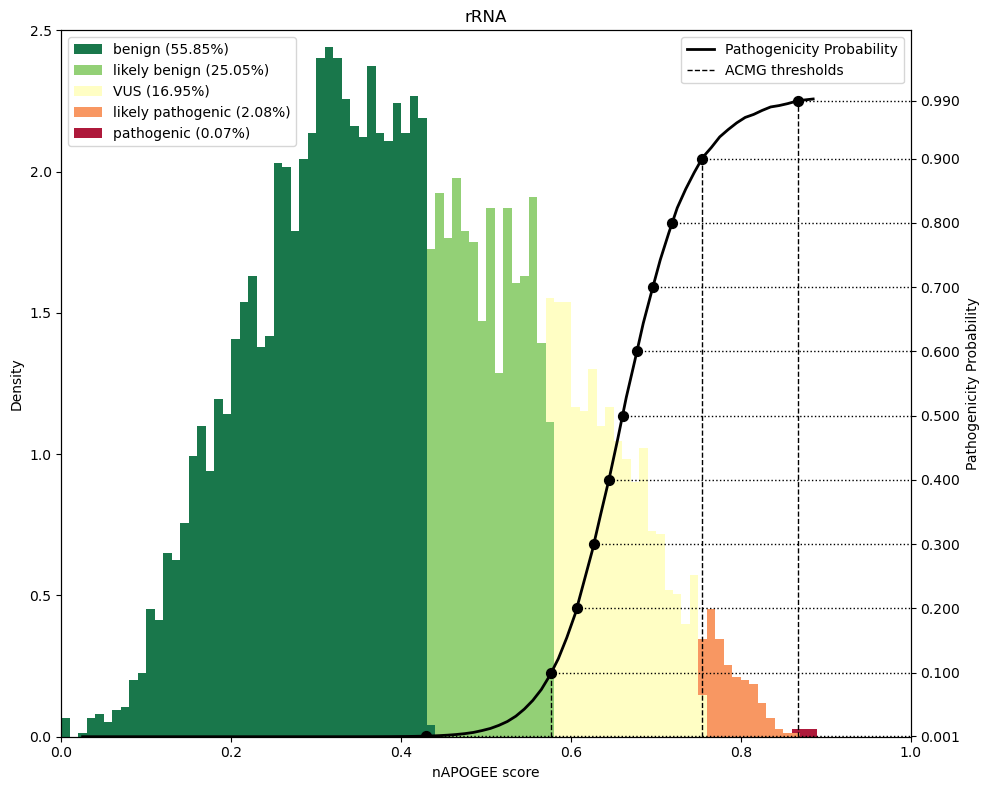

In [7]:
bins_posterior = rapogee_scores.groupby(pd.cut(rapogee_scores.rAPOGEE_oob, bins), observed=False).rAPOGEE_posterior.mean()
bins_posterior.index = (bins[:-1] + bins[1:])/2

# Create figure and primary axis (ax1) for the histogram
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot stacked histogram on primary y-axis
bottom = np.zeros(len(bins) - 1)
for i, cat in enumerate(categories):
    ax1.bar(
        bins[:-1], hist_data_rapogee[cat], width=np.diff(bins),
        bottom=bottom, color=colors[i], alpha=0.9, align='edge',
        label="%s (%.2f%%)" % (cat, (rapogee_scores.category == cat).mean() * 100)
    )
    bottom += hist_data_rapogee[cat]

ax1.set_ylim(-0, 2.5)
ax1.set_xlim(0, 1)
ax1.set_xlabel("nAPOGEE score")
ax1.set_ylabel("Density")
ax1.set_title("rRNA")
ax1.legend(loc="upper left")

# Create secondary axis (ax2) for the posterior values
ax2 = ax1.twinx()
line, = ax2.plot(bins_posterior.index, bins_posterior.values, "k-", linewidth=2, label="Pathogenicity Probability")
proba_ticks = np.linspace(0, 1, 11)
proba_ticks[0] = 0.001
proba_ticks[-1] = 0.99
scores_at_proba_ticks = np.interp(proba_ticks, bins_posterior.values, bins_posterior.index)
plt.scatter(scores_at_proba_ticks, proba_ticks, color="k", s=50)
ax2.hlines(proba_ticks, scores_at_proba_ticks, 1, colors="k", ls=":", lw=1)
ax2.vlines(
    scores_at_proba_ticks[np.isin(proba_ticks, [0.001, 0.1, 0.9, 0.99])], # x
    0, proba_ticks[np.isin(proba_ticks, [0.001, 0.1, 0.9, 0.99])], # y
    colors="k", ls="--", lw=1, label="ACMG thresholds"
)
ax2.set_yticks(proba_ticks)
ax2.set_ylabel("Pathogenicity Probability")
ax2.set_ylim(-0, 1.1)
ax2.legend(loc="upper right")


plt.tight_layout()
plt.savefig("./svg/rAPOGEE_distribution.svg", bbox_inches="tight")
plt.show()